In [54]:

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import ast


In [55]:
dtype=torch.float32
device = 'cpu'

40000


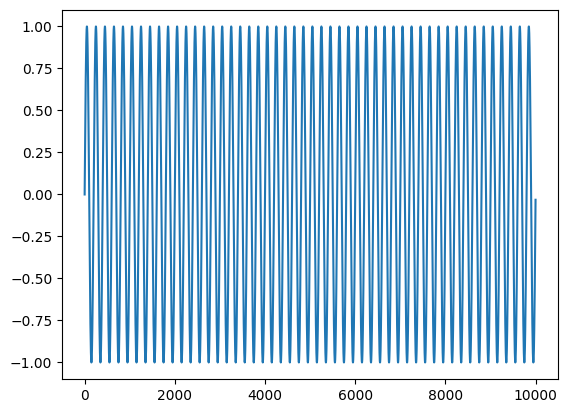

In [56]:
txt = open("N=10000-dt=2.5e-05-force=sin(2pi200t).txt").read().split('\t')
         # list of strings
f = np.array(txt, dtype=float)      # 30000 floats
t = torch.tensor(f[:10000], dtype =dtype)
u= torch.tensor(f[10000:20000],dtype =dtype)
x = torch.tensor(f[20000:30000],dtype =dtype)
v = torch.tensor(f[30000:],dtype =dtype)
print(len(f))
plt.plot(u)


In [58]:
#normalisation 


def zscore_normalize(x: torch.Tensor):
    """
    x: 1D tensor (N,) or (N,1)
    returns: x_norm, mean, std  with x_norm = (x-mean)/std
    """
    if x.dim() == 2 and x.size(1) == 1:
        x = x.view(-1)

    mean = x.mean()
    std = x.std(unbiased=False)  # population std; use unbiased=True if you prefer

    # avoid divide by zero
    std_safe = std.clone()
    if std_safe == 0:
        std_safe = torch.tensor(1.0, dtype=x.dtype, device=x.device)

    x_norm = (x - mean) / std_safe
    return x_norm, mean, std_safe


def zscore_denormalize(x_norm: torch.Tensor, mean: torch.Tensor, std: torch.Tensor):
    """
    Invert z-score: x = x_norm * std + mean
    """
    print('noir')
    print(x_norm)
    print('std')
    print(std)
    return x_norm * std + mean

In [65]:
txt1 = open("N=10000-dt=2.5e-05-force=sin(2pi500t).txt").read().split('\t')
         # list of strings
f1 = np.array(txt1, dtype=float)   

t1=f1[:10000]  # 30000 floats
t1 = torch.tensor(t1, dtype =dtype)
u1 = f1[10000:20000]
u1= torch.tensor(u1,dtype =dtype)
x1=f1[20000:30000]
x1 = torch.tensor(x1,dtype =dtype)
v1=f1[30000:]
v1 = torch.tensor(v1,dtype =dtype)

u1_norm, u1_mean, u1_std = zscore_normalize(u1)
x1_norm , x1_mean, x1_std = zscore_normalize(x1)
v1_norm , v1_mean, v1_std = zscore_normalize(v1)
x01_norm = torch.tensor([x1_norm[0],v1_norm[0]],dtype=torch.float32)

In [59]:
x_train_norm, x_mean, x_std = zscore_normalize(x)
u_train_norm, u_mean, u_std = zscore_normalize(u)
v_train_norm, v_mean, v_std = zscore_normalize(v)

u_v = torch.stack([x[1:], v[1:]] , dim = 0)

Z = torch.stack([x[:-1], v[:-1], u[:-1]], dim=1)  # shape (T-1, 3)
print(Z[0,:].size())
# Targets Y_t = [x_t, v_t]
Y = torch.stack([x[1:], v[1:]], dim=1) 

# Closed-form LS: Y ≈ Z W, W shape (3,2)
Z_T = Z.T                                          # (3, T-1)
W_star = torch.linalg.lstsq(Z_T @ Z, Z_T @ Y).solution  # (3,2)
# Or, more simply (but less stable): W_star = torch.linalg.inv(Z_T @ Z) @ (Z_T @ Y)


torch.Size([3])


In [60]:
k = (2*np.pi*100)**2
m = 1
zeta, f_n = 0.015, 100.0      # 100 Hz
wn = 2 * np.pi * f_n
c = 2 * zeta * m * wn

# dt = t[1].item()
dt = 2.5e-5
N = len(t)
print(N)
print(dt)
N_list = np.arange(N)*dt
Nl = torch.tensor(N_list, dtype=dtype, device=device)
print(f'time increment: {dt} s, total time: {N*dt} s')
I2 = torch.tensor([[1,0],[0,1]], dtype=dtype).to(device)
A2 = torch.tensor([[0,1],[-k/m,-c/m]], dtype=dtype).to(device)
B2 = torch.tensor([[0],[1/m]], dtype=dtype).to(device)


Adisc = torch.linalg.inv(I2-dt*0.5*A2)@(I2+dt*0.5*A2)
Bdisc = torch.linalg.inv(I2-dt*0.5*A2)@(dt*B2)
x0_norm = torch.stack([x_train_norm[0], v_train_norm[0]])
x0 = torch.stack([torch.tensor(0),torch.tensor(0)])

10000
2.5e-05
time increment: 2.5e-05 s, total time: 0.25 s


[]

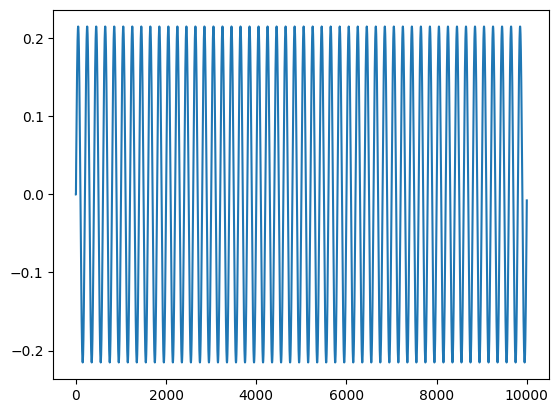

In [61]:

class NARX(nn.Module):
    def __init__(self, A=None, B=None):
        super().__init__()
        self.hidden = nn.Linear(3, 2, bias=False)

        with torch.no_grad():
            if A is not None and B is not None:
                C = torch.cat((A, B), dim=1)   # shape (2, 3)
                self.hidden.weight.copy_(C)

    def forward(self, u, x0=None):
        if x0 is None:
            x0 = torch.tensor([0.0, 0.0], dtype=torch.float32, device=u.device)

        out = [x0]
        for i in range(1, len(u)):
            h_prev = out[i - 1]
            u_prev = u[i - 1].view(1)
            inp = torch.cat((h_prev, u_prev), dim=0)   # (3,)
            xi = self.hidden(inp)                      # (2,)
            out.append(xi)

        return torch.stack(out, dim=0)[:, 0]

    def train_propegate(self, input):
        return self.hidden(input)


def train_model_sgd(
    model,
    optimizer,
    x_train,
    v_train,
    f_train,
    epochs=500,
    lossfcn=nn.MSELoss(),
    exit_tol=1e-14
):
    model.train()

    # one-step supervised pairs:
    # input  = [x_k, v_k, f_k]
    # target = [x_{k+1}, v_{k+1}]
    Z = torch.stack([x_train[:-1], v_train[:-1], f_train[:-1]], dim=1)   # (N-1, 3)
    Y = torch.stack([x_train[1:],  v_train[1:]], dim=1)                   # (N-1, 2)

    N = Z.shape[0]
    loss_history = []

    for epoch in range(epochs):
        perm = torch.randperm(N)
        epoch_loss = 0.0

        for i in perm:
            z_i = Z[i]          # single training example, shape (3,)
            y_i = Y[i]          # single target, shape (2,)

            optimizer.zero_grad()

            y_hat = model.train_propegate(z_i)   # predicts [x_{k+1}, v_{k+1}]
            loss = lossfcn(y_hat, y_i)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        epoch_loss /= N
        loss_history.append(epoch_loss)

        if epoch_loss < exit_tol:
            print(f"Stopping early at epoch {epoch}, loss = {epoch_loss:.3e}")
            break

        if epoch % 50 == 0:
            print(f"Epoch {epoch}: loss = {epoch_loss:.6e}")

    return loss_history


modelpert = NARX()
optimiserpert = torch.optim.SGD(modelpert.parameters(), lr=1e-3)

predpre = modelpert(u)
plt.plot(predpre.detach())
plt.plot()

In [62]:

loss_history = train_model_sgd(
    modelpert,
    optimiserpert,
    x_train_norm,
    v_train_norm,
    u_train_norm,   # this is your input force sequence
    epochs=400,
    exit_tol=1e-16
)

Epoch 0: loss = 7.429717e-02
Epoch 50: loss = 6.790121e-09
Epoch 100: loss = 6.793955e-09
Epoch 150: loss = 6.793851e-09
Epoch 200: loss = 6.792573e-09
Epoch 250: loss = 6.792084e-09
Epoch 300: loss = 6.794628e-09
Epoch 350: loss = 6.792731e-09


noir
tensor([-0.0120, -0.0120, -0.0120,  ...,  0.0723,  0.0427,  0.0130],
       grad_fn=<SelectBackward0>)
std
tensor(8.1011e-07)


[]

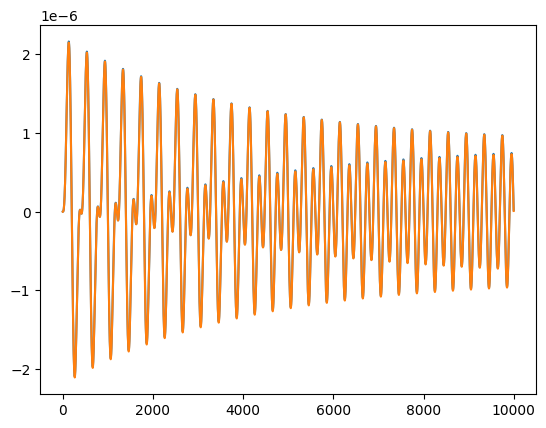

In [63]:
pred = modelpert(u_train_norm,x0_norm)
predaf = zscore_denormalize(pred, x_mean, x_std)
plt.plot(predaf.detach())
plt.plot(x)
plt.plot()

noir
tensor([-0.0163, -0.0163, -0.0162,  ...,  0.0264,  0.0173,  0.0081],
       grad_fn=<SelectBackward0>)
std
tensor(8.1011e-07)


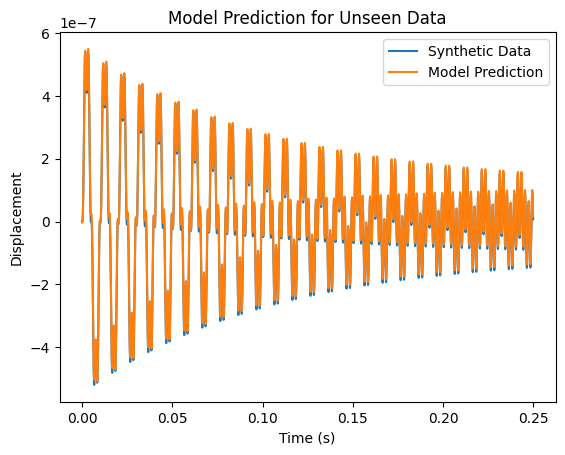

In [66]:
test_pred = modelpert(u1_norm, x01_norm)

test_pred = zscore_denormalize(test_pred, x_mean,x_std)
plt.plot(t, x1, label = 'Synthetic Data')
plt.plot(t, test_pred.detach(), label = 'Model Prediction')
plt.legend()

plt.title("Model Prediction for Unseen Data")
plt.xlabel("Time (s)")          # x‑axis label
plt.ylabel("Displacement")
plt.show()

# data = [['time'],t.numpy(),['synthetic x'], x1,['model after train unseen'], test_pred]

# filename = f'Data/4-2neuronnarx-batch-unseen-data.txt'

# tstr = '\t'.join(str(x) for lst in data for x in lst)

# with open(filename, "w") as f:
#   f.write(tstr)


In [77]:
w = modelpert.hidden.weight[:]
print(w)
A = torch.tensor([[ 9.9975e-01,  2.5460e-02],
        [-9.6883e-03,  9.9953e-01]])
print(A)

eig = torch.linalg.eigvals(A)
print(eig)
print(abs(eig[0]))

tensor([[ 9.9975e-01,  2.5460e-02,  5.4164e-04],
        [-9.6883e-03,  9.9953e-01,  2.1416e-02]], grad_fn=<SliceBackward0>)
tensor([[ 0.9998,  0.0255],
        [-0.0097,  0.9995]])
tensor([0.9996+0.0157j, 0.9996-0.0157j])
tensor(0.9998)
